In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
    "use_gpu":use_gpu
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
  #  "use_gpu":use_gpu
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

m1 = 1e6
m2 = 10
a = 0.8 # 0.95
e0 = 0.4 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.2

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

print(use_gpu)
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [4]:
der_order = 8
Ndelta=10
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 631163)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  41.71176563349507


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 631163)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 41.71176563349507
calculating stable deltas...
Gamma_ii for m1: 21.40761398570681
Gamma_ii for m1: 21.407613985615114
Gamma_ii for m1: 21.407613986369892
Gamma_ii for m1: 21.407613986901524
Gamma_ii for m1: 21.40761398548391
Gamma_ii for m1: 21.407614033115657
Gamma_ii for m1: 21.407613951310324
Gamma_ii for m1: 21.407613614076677
Gamma_ii for m1: 21.407611538373388
Gamma_ii for m1: 21.407616168579477
[np.float64(4.283314343740312e-12), np.float64(3.525743570747342e-11), np.float64(2.483376372232189e-11), np.float64(6.622010613687585e-11), np.float64(2.2249909476824323e-09), np.float64(3.821319483433589e-09), np.float64(1.575297710940775e-08), np.float64(9.69609937815678e-08), np.f

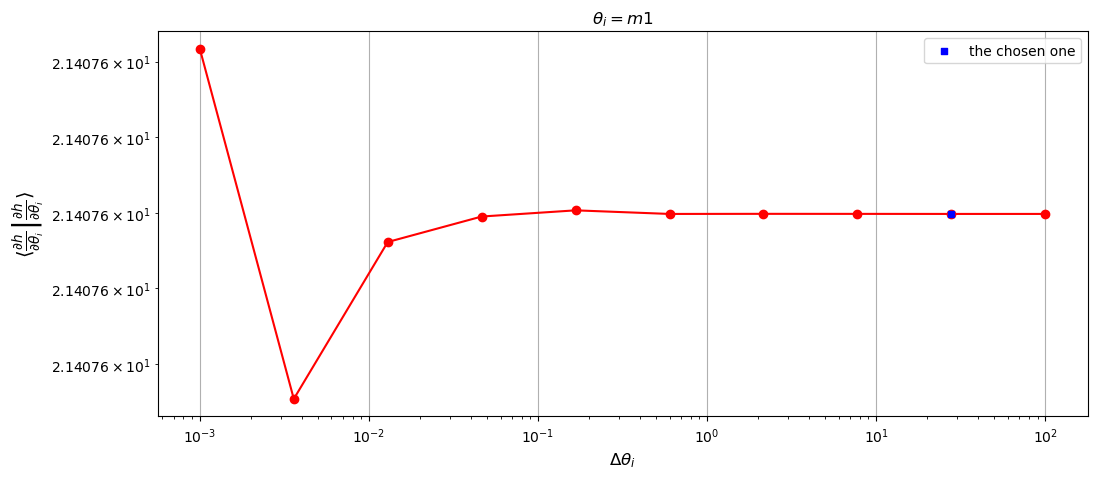

Gamma_ii for m2: 250672323.61392573
Gamma_ii for m2: 250672323.61278355
Gamma_ii for m2: 250672323.93133524
Gamma_ii for m2: 250672322.53927988
Gamma_ii for m2: 250672326.2285006
Gamma_ii for m2: 250672322.2756209
Gamma_ii for m2: 250672326.91748673
Gamma_ii for m2: 250672469.3409588
Gamma_ii for m2: 250671388.34166878
Gamma_ii for m2: 250673224.96156
[np.float64(4.5564424067523e-12), np.float64(1.27078922950276e-09), np.float64(5.553287049649708e-09), np.float64(1.471730358909706e-08), np.float64(1.5769111089728248e-08), np.float64(1.8517663584064325e-08), np.float64(5.681655925403335e-07), np.float64(4.312415936939144e-06), np.float64(7.326749362672985e-06)]
0


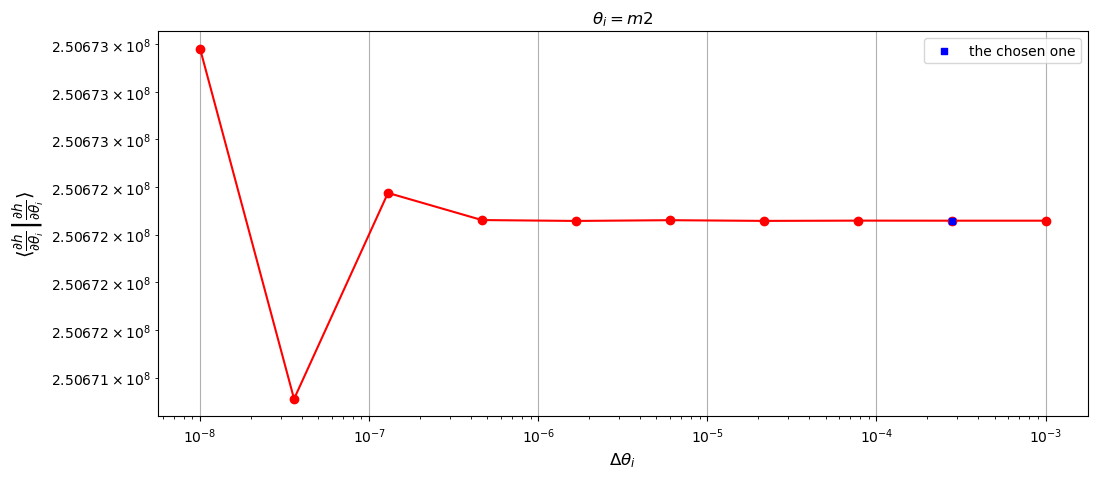

Gamma_ii for a: 41882488990.64592
Gamma_ii for a: 41882492371.695244
Gamma_ii for a: 41882430723.38428
Gamma_ii for a: 41882338854.875565
Gamma_ii for a: 41881923876.700294
Gamma_ii for a: 41882472530.349976
Gamma_ii for a: 41894969912.758255
Gamma_ii for a: 41861377144.050766
Gamma_ii for a: 41928086080.53152
Gamma_ii for a: 41826352263.087875
[np.float64(8.072703252781115e-08), np.float64(1.471937275409173e-06), np.float64(2.19349041205883e-06), np.float64(9.908288274716548e-06), np.float64(1.3099839062355058e-05), np.float64(0.00029830269443572503), np.float64(0.0008024764353043539), np.float64(0.0015910322343982695), np.float64(0.0024322899784264156)]
0


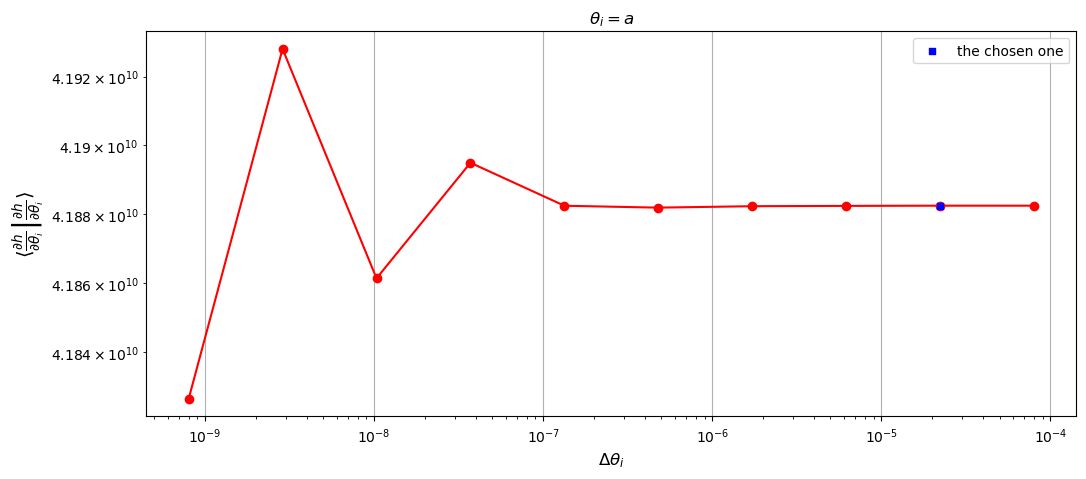

Gamma_ii for p0: 723659603258.8575
Gamma_ii for p0: 723659536722.998
Gamma_ii for p0: 723659596211.6165
Gamma_ii for p0: 723659750224.217
Gamma_ii for p0: 723660235867.2512
Gamma_ii for p0: 723659495451.945
Gamma_ii for p0: 723634493470.342
Gamma_ii for p0: 723630903058.7097
Gamma_ii for p0: 723622053066.2678
Gamma_ii for p0: 723618576463.0071
[np.float64(9.194359518616952e-08), np.float64(8.220525053440616e-08), np.float64(2.1282460512446437e-07), np.float64(6.710926068746635e-07), np.float64(1.0231542748043467e-06), np.float64(3.455056638193543e-05), np.float64(4.961661555840051e-06), np.float64(1.223013091487977e-05), np.float64(4.8044693348470425e-06)]
1


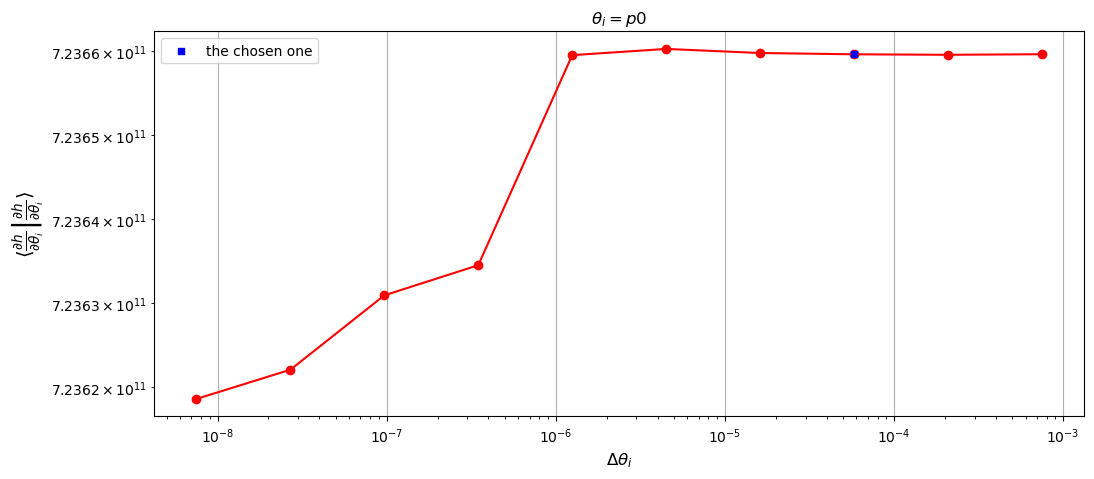

Gamma_ii for e0: 20518514407378.324
Gamma_ii for e0: 20518516433649.613
Gamma_ii for e0: 20518507752375.426
Gamma_ii for e0: 20518429492729.75
Gamma_ii for e0: 20518284698850.87
Gamma_ii for e0: 20518836233388.176
Gamma_ii for e0: 20520088515278.72
Gamma_ii for e0: 20524173148686.65
Gamma_ii for e0: 20495598093647.59
Gamma_ii for e0: 20543481246531.19
[np.float64(9.87533039055148e-08), np.float64(4.230948123649474e-07), np.float64(3.814114803645709e-06), np.float64(7.056821805724113e-06), np.float64(2.6879425861747096e-05), np.float64(6.102711933286996e-05), np.float64(0.00019901573516938807), np.float64(0.0013942044973996222), np.float64(0.0023308198016189067)]
0


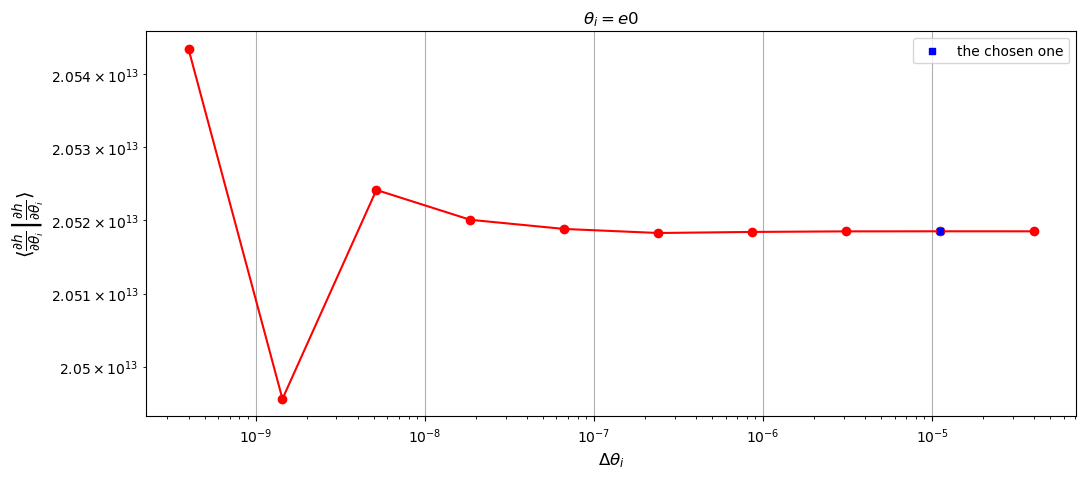

Gamma_ii for qS: 5356.219367909812
Gamma_ii for qS: 5356.219374661335
Gamma_ii for qS: 5356.219374661523
Gamma_ii for qS: 5356.219374661649
Gamma_ii for qS: 5356.219374660839
Gamma_ii for qS: 5356.219374660225
Gamma_ii for qS: 5356.219374649627
Gamma_ii for qS: 5356.219374663596
Gamma_ii for qS: 5356.21937476883
Gamma_ii for qS: 5356.2193748413165
[np.float64(1.2605015754577088e-09), np.float64(3.514893436919642e-14), np.float64(2.360242452810718e-14), np.float64(1.5129323924134303e-13), np.float64(1.146160903343639e-13), np.float64(1.978698223213312e-12), np.float64(2.6079830095472408e-12), np.float64(1.9647065700680017e-11), np.float64(1.35331887397629e-11)]
2


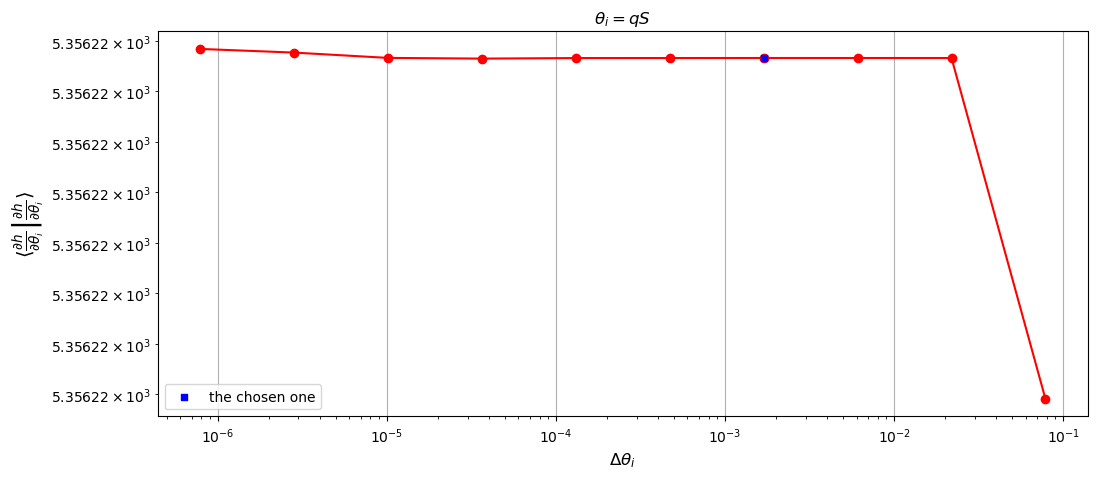

Gamma_ii for phiS: 103111.93247663214
Gamma_ii for phiS: 103111.93247530714
Gamma_ii for phiS: 103111.93247530708
Gamma_ii for phiS: 103111.93247530708
Gamma_ii for phiS: 103111.9324753071
Gamma_ii for phiS: 103111.9324753071
Gamma_ii for phiS: 103111.93247530719
Gamma_ii for phiS: 103111.93247530719
Gamma_ii for phiS: 103111.93247530413
Gamma_ii for phiS: 103111.93247531104
[np.float64(1.2850069875334671e-11), np.float64(5.645094560458053e-16), np.float64(0.0), np.float64(1.411273640114513e-16), np.float64(0.0), np.float64(8.467641840687071e-16), np.float64(0.0), np.float64(2.963674644240563e-14), np.float64(6.703549790543681e-14)]
2


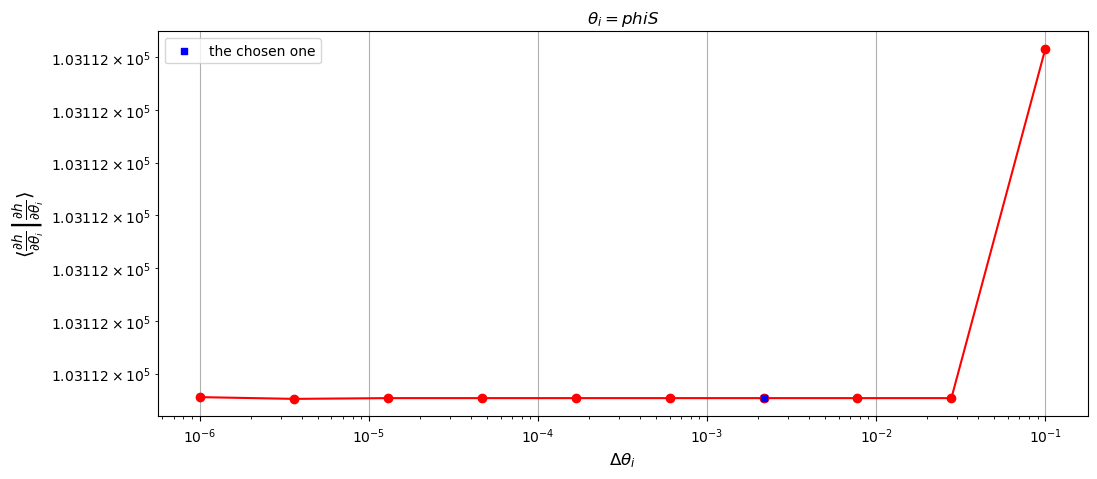

Gamma_ii for dev0p: 12301758905.187817
Gamma_ii for dev0p: 12301780694.128899
Gamma_ii for dev0p: 12301710888.837635
Gamma_ii for dev0p: 12302353717.368023
Gamma_ii for dev0p: 12302364484.794237
Gamma_ii for dev0p: 12306288330.03783
Gamma_ii for dev0p: 12296990167.369047
Gamma_ii for dev0p: 12334560954.363848
Gamma_ii for dev0p: 12369916293.66365
Gamma_ii for dev0p: 11120219456.950924
[np.float64(1.771202204279226e-06), np.float64(5.674437636712831e-06), np.float64(5.2252483155345804e-05), np.float64(8.752322553543844e-07), np.float64(0.0003188487981397031), np.float64(0.0007561332116420272), np.float64(0.0030459768396951647), np.float64(0.0028581712649028315), np.float64(0.1123805911880253)]
3


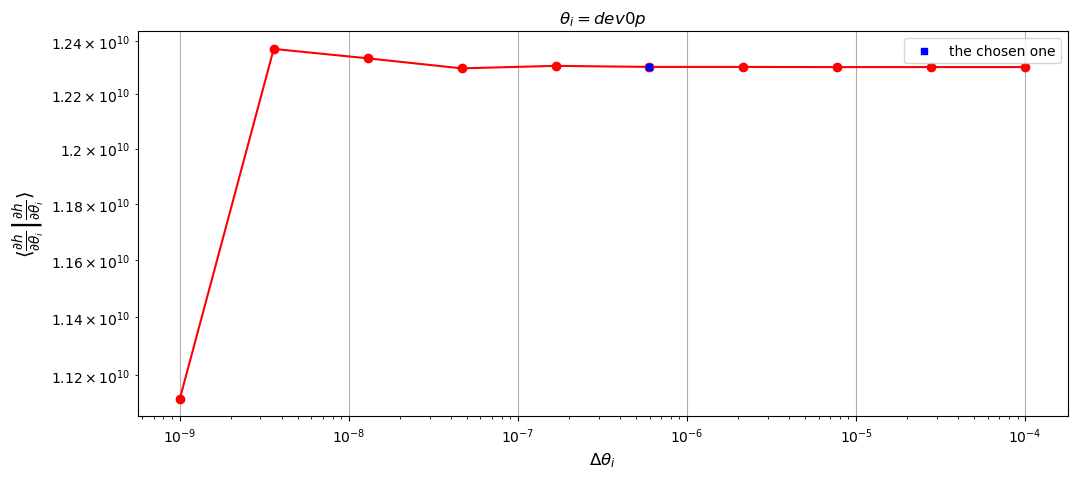

Gamma_ii for dev0e: 2256618890.6316056
Gamma_ii for dev0e: 2256641061.2718453
Gamma_ii for dev0e: 2256606438.9322524
Gamma_ii for dev0e: 2256452849.061381
Gamma_ii for dev0e: 2256228451.444789
Gamma_ii for dev0e: 2258225682.4511347
Gamma_ii for dev0e: 2251978085.67279
Gamma_ii for dev0e: 2213146950.4711285
Gamma_ii for dev0e: 2261879662.495026
Gamma_ii for dev0e: 2413727957.0344296
[np.float64(9.824619705900495e-06), np.float64(1.5342657450412904e-05), np.float64(6.806695337570773e-05), np.float64(9.945695722799528e-05), np.float64(0.000884424892457119), np.float64(0.0027742706814476523), np.float64(0.017545665096208512), np.float64(0.02154522755208902), np.float64(0.0629102770661729)]
0


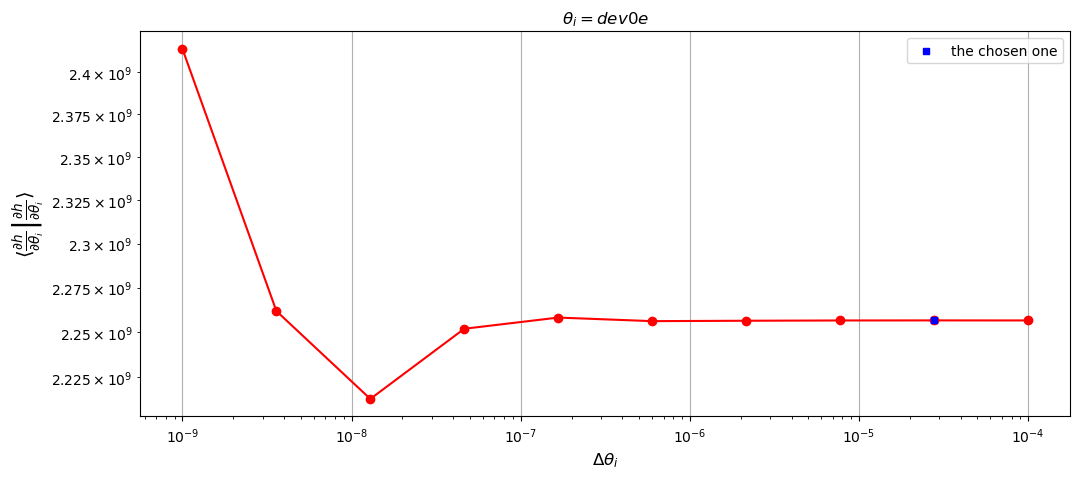

stable deltas: {'m1': 27.825594022071243, 'm2': 0.0002782559402207126, 'a': 2.2260475217657015e-05, 'p0': 5.806977620108459e-05, 'e0': 1.1130237608828506e-05, 'qS': 0.0016920890487107918, 'phiS': 0.002154434690031882, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 5.994842503189409e-07, 'dev0e': 2.782559402207126e-05}
Time taken to compute stable deltas is 41.41054368019104 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 4.148634910583496 seconds


In [5]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [6]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher, m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_0_p,dev_0_e])

In [7]:
chi2=0
deviation_included=True
evolve_1PA=False
evolve_primary=False
evolve_2PA=False
use_gpu=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)

waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
waveform_true=xp.array(waveform_true)

[0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [8]:
chi2=0
deviation_included=True
evolve_1PA=False
evolve_primary=False
evolve_2PA=False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

def loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_):
    add_args__ = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,\
                dev0p_,dev0e_,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS_, phiS_, qK, phiK, Phi_phi0_, Phi_theta0, Phi_r0_, *add_args__, dt=dt, T=T,use_gpu=use_gpu))

    diff_inner=inner_product(waveform_true-waveform_temp,waveform_true-waveform_temp,PSD,dt,use_gpu=use_gpu)
    #print(diff_inner)
    return -0.5 * diff_inner



In [9]:
loglike_calc(m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e)

np.float64(-0.0)

In [10]:
def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)
    for i in range(n_samples):
        logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]
        m1_ = np.exp(logm1_)

        loglike = loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_)
        log_likes[i] = loglike 
    return log_likes

n=5
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]
qSlim = [params_truth_in[5] - n*std[5], params_truth_in[5] + n*std[5]]
phiSlim = [params_truth_in[6] - n*std[6], params_truth_in[6] + n*std[6]]
Phi_phi0lim = [params_truth_in[7] - n*std[7], params_truth_in[7] + n*std[7]]
Phi_r0lim = [params_truth_in[8] - n*std[8], params_truth_in[8] + n*std[8]]
dev0plim = [params_truth_in[9] - n*std[9], params_truth_in[9] + n*std[9]]
dev0elim = [params_truth_in[10] - n*std[10], params_truth_in[10] + n*std[10]]

def prior_transform(u):

    transformed = np.zeros_like(u)
    # Uniform in log for masses
    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (m2lim[1] - m2lim[0]) * u[:, 1] + m2lim[0]

    # Linear in others 
    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    transformed[:, 5] = (qSlim[1] - qSlim[0]) * u[:, 5] + qSlim[0]
    transformed[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    transformed[:, 7] = (Phi_phi0lim[1] - Phi_phi0lim[0]) * u[:, 7] + Phi_phi0lim[0]
    transformed[:, 8] = (Phi_r0lim[1] - Phi_r0lim[0]) * u[:, 8] + Phi_r0lim[0]
    transformed[:, 9] = (dev0plim[1] - dev0plim[0]) * u[:, 9] + dev0plim[0]
    transformed[:, 10] = (dev0elim[1] - dev0elim[0]) * u[:, 10] + dev0elim[0]

    return transformed

    
def inverse_prior_transform(x):
    
    u = np.zeros_like(x)

    u[:, 0] = (x[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (x[:, 1] - m2lim[0]) / (m2lim[1] - m2lim[0])
    u[:, 2] = (x[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (x[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (x[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (x[:, 5] - qSlim[0]) / (qSlim[1] - qSlim[0])
    u[:, 6] = (x[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    u[:, 7] = (x[:, 7] - Phi_phi0lim[0]) / (Phi_phi0lim[1] - Phi_phi0lim[0])
    u[:, 8] = (x[:, 8] - Phi_r0lim[0]) / (Phi_r0lim[1] - Phi_r0lim[0])
    u[:, 9] = (x[:, 9] - dev0plim[0]) / (dev0plim[1] - dev0plim[0])
    u[:, 10] = (x[:, 10] - dev0elim[0]) / (dev0elim[1] - dev0elim[0])
    
    return u

In [11]:

logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]
qSlim = [params_truth_in[5] - n*std[5], params_truth_in[5] + n*std[5]]
phiSlim = [params_truth_in[6] - n*std[6], params_truth_in[6] + n*std[6]]
Phi_phi0lim = [params_truth_in[7] - n*std[7], params_truth_in[7] + n*std[7]]
Phi_r0lim = [params_truth_in[8] - n*std[8], params_truth_in[8] + n*std[8]]
dev0plim = [params_truth_in[9] - n*std[9], params_truth_in[9] + n*std[9]]
dev0elim = [params_truth_in[10] - n*std[10], params_truth_in[10] + n*std[10]]
ranges=[logm1lim, m2lim, alim, p0lim, e0lim, qSlim, phiSlim, Phi_phi0lim, Phi_r0lim, dev0plim, dev0elim]
ranges

[[np.float64(13.692081825532524), np.float64(13.938939290396023)],
 [np.float64(9.35332106243888), np.float64(10.64667893756112)],
 [np.float64(0.7180287150758408), np.float64(0.8819712849241593)],
 [np.float64(7.0210353063730215), np.float64(7.9789646936269785)],
 [np.float64(0.36799597531327927), np.float64(0.4320040246867208)],
 [np.float64(0.5528776445828361), np.float64(1.0179186822120605)],
 [np.float64(0.728535986715054), np.float64(1.271464013284946)],
 [np.float64(-0.22382320370471176), np.float64(2.023823203704712)],
 [np.float64(0.06265112715881288), np.float64(0.7373488728411872)],
 [np.float64(-0.1136049360291562), np.float64(0.1136049360291562)],
 [np.float64(-0.1735694635491439), np.float64(0.1735694635491439)]]

In [12]:
# def main():
    
config = SamplerConfig(
    merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
    alpha=2000,                    # Use recent samples for weighting
    trail_size=int(1e3),          # Maximum trials per iteration
    boundary_limiting=True,        # Enable boundary constraints
    use_beta=True,                # Use beta correction for boundaries
    integral_num=int(1e5),        # MC samples for beta estimation
    gamma=500,                    # Covariance update frequency
    exclude_scale_z=10,       # No exclusion based on weights
    use_pool=False,               # Set to True for multiprocessing
    # n_pool=4                     # Number of processes (if use_pool=True)
)

ndim = 11
n_seed = 1  # Number of initial processes
init_cov_list = [np.eye(ndim) * 0.05] * n_seed
savepath = 'paris_check'

# Create save directory
os.makedirs(savepath, exist_ok=True)

print(f"Problem dimension: {ndim}")
print(f"Number of processes: {n_seed}")
print(f"Save path: {savepath}")
print(f"Multiprocessing: {config.use_pool}")
# Initialize sampler
print("\nInitializing sampler...")
sampler = Sampler(
    ndim=ndim, 
    n_seed=n_seed,
    log_density_func=log_density,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)
   # Prepare initial samples using Latin Hypercube Sampling
print("Preparing LHS samples...")
# sampler.prepare_lhs_samples(lhs_num=int(5e4), batch_size=50)
external_lhs_points = np.array([params_truth_in])
external_lhs_points = inverse_prior_transform(external_lhs_points)
external_lhs_log_densities = log_density(prior_transform(external_lhs_points))
print("true points in corrrect space",params_truth_in)
print("external lhs_points: ", external_lhs_points)
print("external_lhs_log_densities", external_lhs_log_densities)


# external_lhs_points = np.vstack(external_lhs_points)
# external_lhs_log_densities = np.concatenate(external_lhs_log_densities)

sampler.run_sampling(
            num_iterations=2000,
            savepath=savepath,
            print_iter=100,
            external_lhs_points=external_lhs_points,
            external_lhs_log_densities=external_lhs_log_densities,
        )
#except Exception as exc:
 #       print(f"[WARN] PARIS sampling failed: {exc}")
    
# Gt results
print("Extracting results...")
samples_, weights_ = sampler.get_samples_with_weights(flatten=True)

# Basic analysis
print(f"\nResults Summary:")
print(f"Total samples: {len(samples_)}")
print(f"Effective sample size: {1/np.sum(weights_  **2):.1f}")

# Weighted statistics
weighted_mean = np.average(samples_, weights=weights_, axis=0)
weighted_cov = np.cov(samples_.T, aweights=weights_)

print(f"\nTrue values: {params_truth_in}")
print(f"Estimated deviation: {weighted_mean}")
print(f"Mean deviation: {np.linalg.norm(weighted_mean - params_truth_in):.6f}")

print(f"\nTrue covariance diagonal: {np.diag(cov)}")
print(f"Estimated covariance diagonal: {np.diag(weighted_cov)}")

# if __name__ == "__main__":

#     main()



Problem dimension: 11
Number of processes: 1
Save path: paris_check
Multiprocessing: False

Initializing sampler...
Preparing LHS samples...
true points in corrrect space [13.81551056 10.          0.8         7.5         0.4         0.78539816
  1.          0.9         0.4         0.          0.        ]
external lhs_points:  [[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]]
external_lhs_log_densities [-2.90685433e-18]


Sampling:   0%|          | 0/1999 [00:00<?, ?it/s]

/home/svu/e1583490/scratch/parismc/parismc/sampler.py:765: RuntimeWarning: divide by zero encountered in log
  logZ = c_term - np.log(Nsum) + np.log(wsum)
/home/svu/e1583490/scratch/parismc/parismc/sampler.py:765: RuntimeWarning: invalid value encountered in scalar add
  logZ = c_term - np.log(Nsum) + np.log(wsum)
Negative or close zero determinant covariance matrix, seed 0, sign 0.0, log_det_cov -inf
Negative or close zero determinant covariance matrix, seed 0, sign 0.0, log_det_cov -inf
Negative or close zero determinant covariance matrix, seed 0, sign 0.0, log_det_cov -inf


Extracting results...

Results Summary:
Total samples: 2000
Effective sample size: 22684942.8

True values: [13.81551056 10.          0.8         7.5         0.4         0.78539816
  1.          0.9         0.4         0.          0.        ]
Estimated deviation: [13.81551056 10.          0.8         7.5         0.4         0.78539816
  1.          0.9         0.4         0.          0.        ]
Mean deviation: 0.000000

True covariance diagonal: [6.09386080e-04 1.67277459e-02 2.68771662e-04 9.17628711e-03
 4.09703038e-05 2.16263167e-03 2.94770842e-03 5.05191437e-02
 4.55217048e-03 5.16243260e-04 1.20505435e-03]
Estimated covariance diagonal: [nan nan nan nan nan nan nan nan nan nan nan]


/tmp/ipykernel_23950/1902208804.py:73: RuntimeWarning: Degrees of freedom <= 0 for slice
  weighted_cov = np.cov(samples_.T, aweights=weights_)
/home/svu/e1583490/anaconda3/envs/few_gpu/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/svu/e1583490/anaconda3/envs/few_gpu/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [ ]:
c=log_density(samples_)
len(c[c<-1000])

1999

[[np.float64(13.692081825532524), np.float64(13.938939290396023)], [np.float64(9.35332106243888), np.float64(10.64667893756112)], [np.float64(0.7180287150758408), np.float64(0.8819712849241593)], [np.float64(7.0210353063730215), np.float64(7.9789646936269785)], [np.float64(0.36799597531327927), np.float64(0.4320040246867208)], [np.float64(0.5528776445828361), np.float64(1.0179186822120605)], [np.float64(0.728535986715054), np.float64(1.271464013284946)], [np.float64(-0.22382320370471176), np.float64(2.023823203704712)], [np.float64(0.06265112715881288), np.float64(0.7373488728411872)], [np.float64(-0.1136049360291562), np.float64(0.1136049360291562)], [np.float64(-0.1735694635491439), np.float64(0.1735694635491439)]]


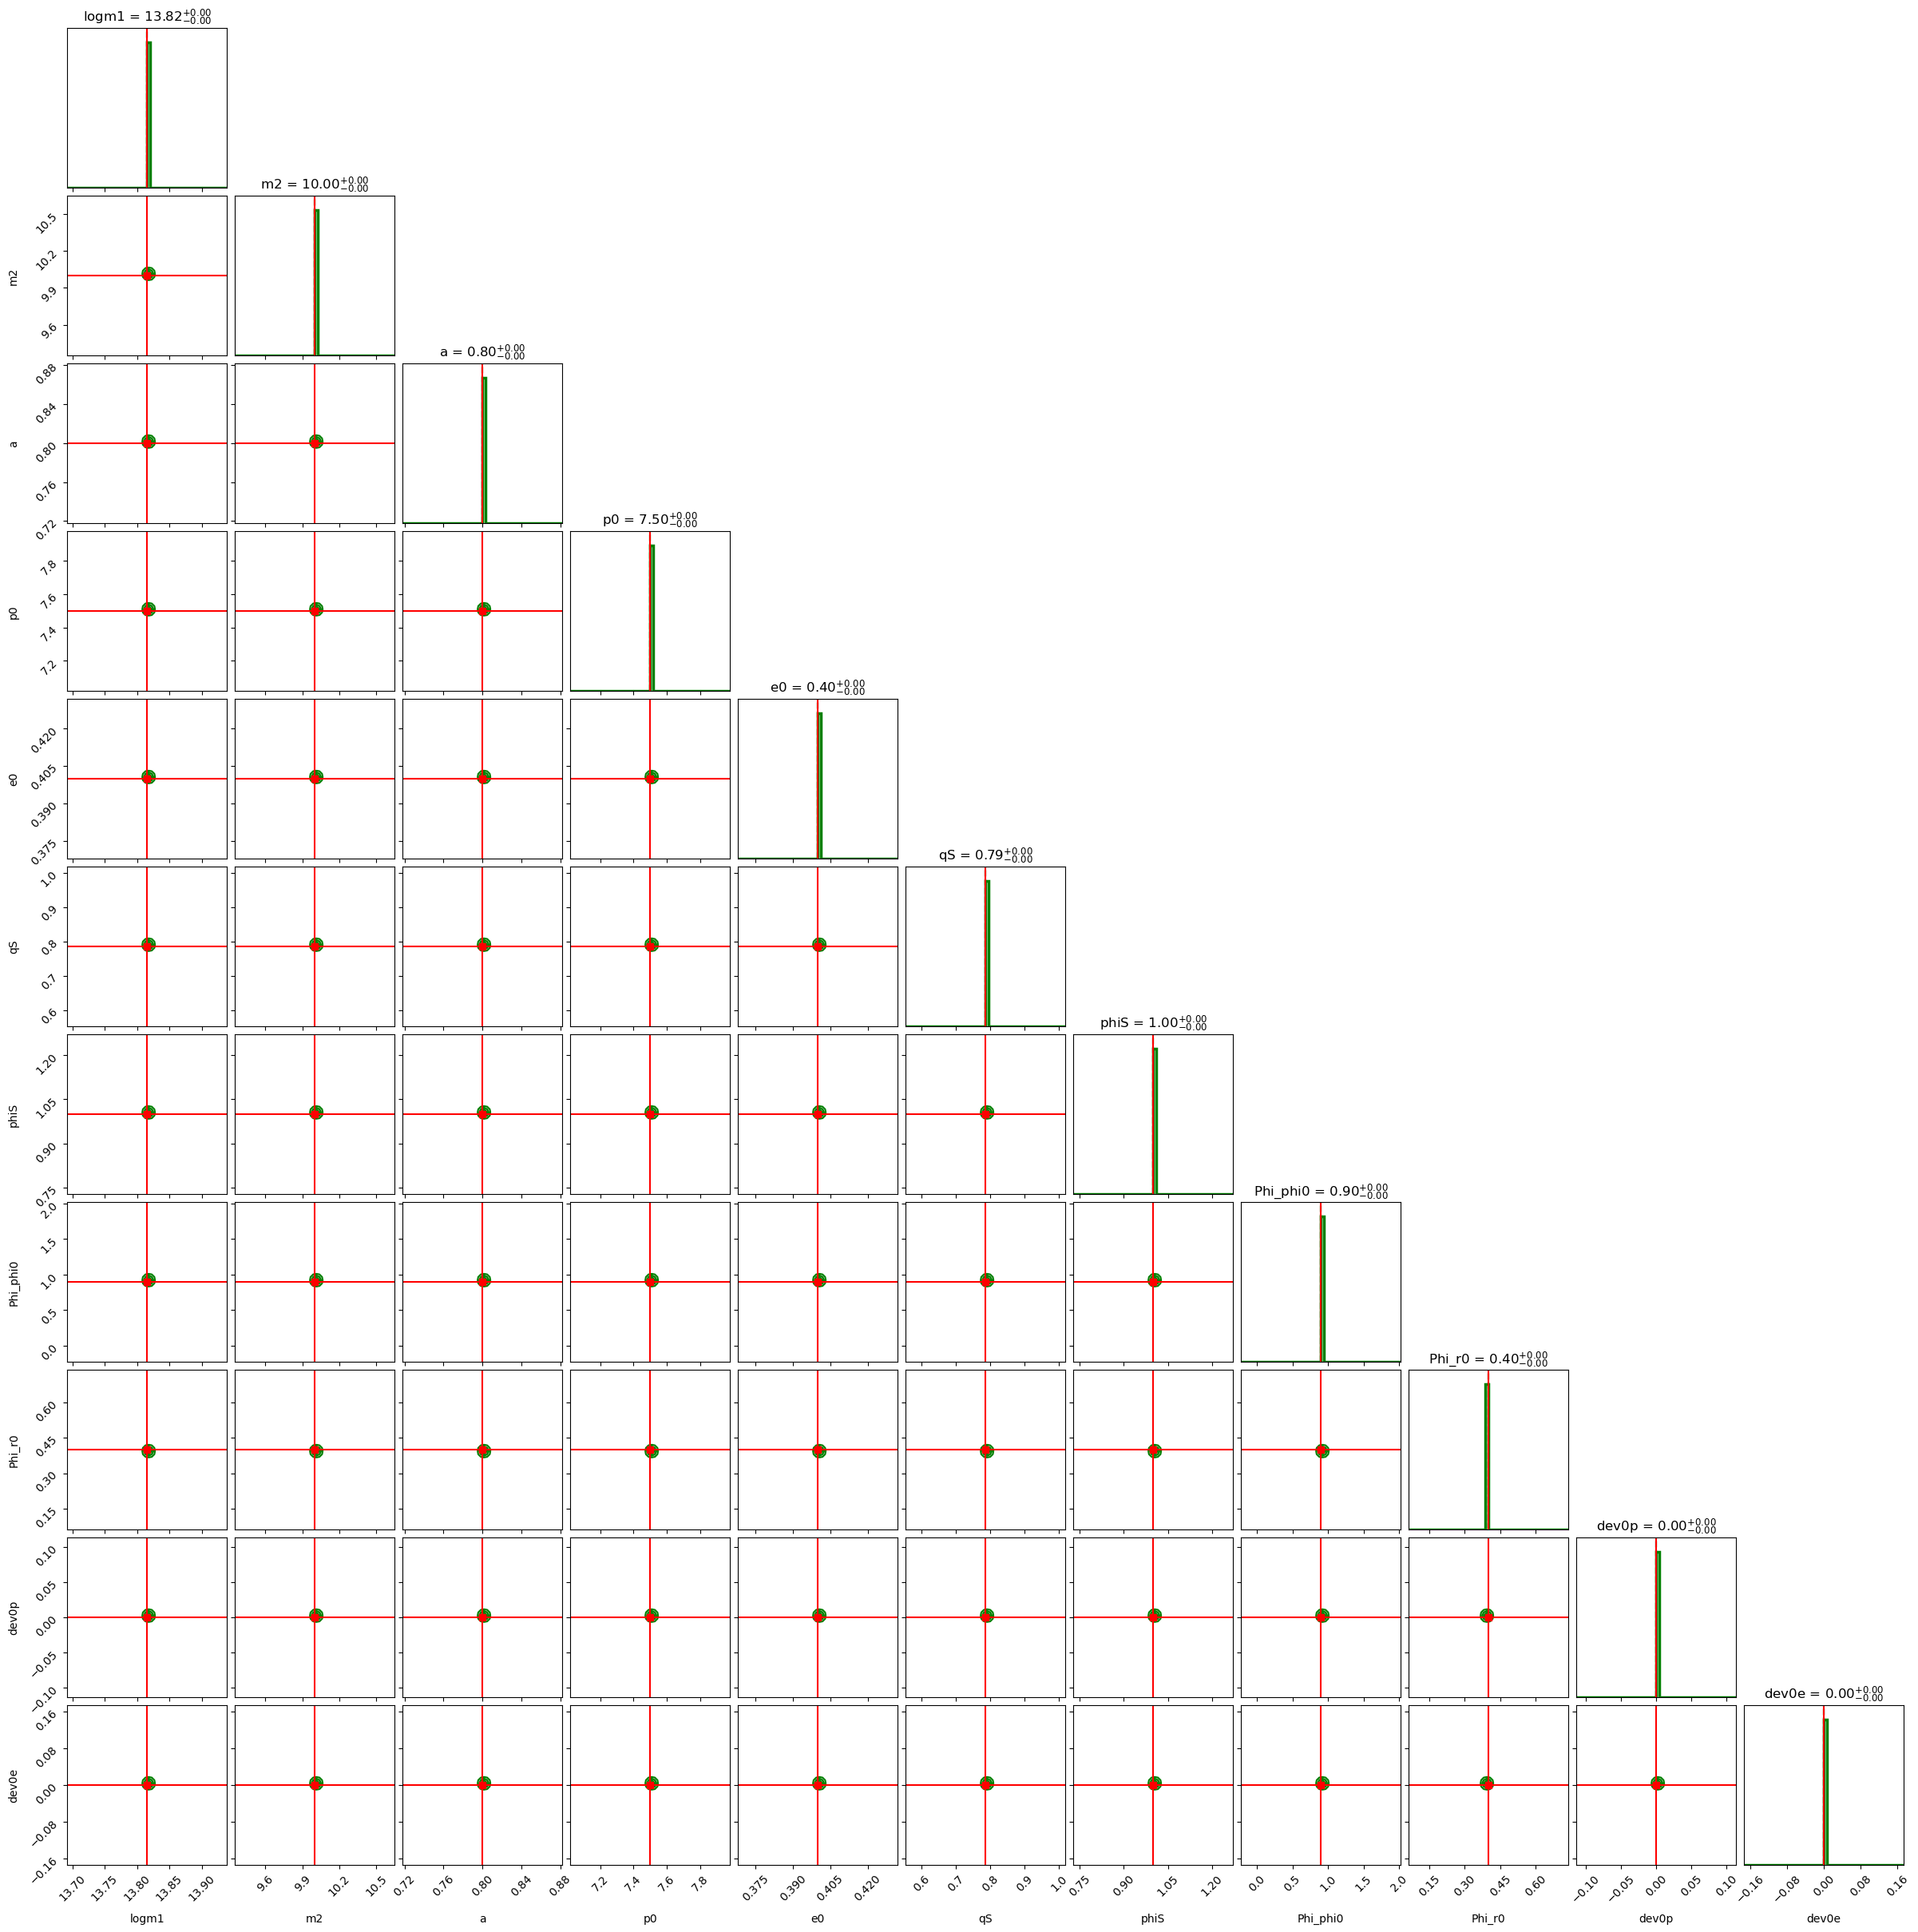

In [16]:
import corner
n=5
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]
qSlim = [params_truth_in[5] - n*std[5], params_truth_in[5] + n*std[5]]
phiSlim = [params_truth_in[6] - n*std[6], params_truth_in[6] + n*std[6]]
Phi_phi0lim = [params_truth_in[7] - n*std[7], params_truth_in[7] + n*std[7]]
Phi_r0lim = [params_truth_in[8] - n*std[8], params_truth_in[8] + n*std[8]]
dev0plim = [params_truth_in[9] - n*std[9], params_truth_in[9] + n*std[9]]
dev0elim = [params_truth_in[10] - n*std[10], params_truth_in[10] + n*std[10]]
ranges=[logm1lim, m2lim, alim, p0lim, e0lim, qSlim, phiSlim, Phi_phi0lim, Phi_r0lim, dev0plim, dev0elim]
param_ranges= [logm1lim,m2lim,alim,p0lim,e0lim,qSlim,phiSlim,Phi_phi0lim,Phi_r0lim,dev0plim,dev0elim]



# scale ranges → must become list of (min, max) tuples
# param_ranges = [(l[0] * n_scaling, l[1] * n_scaling) for l in param_ranges]
print(param_ranges)

labels = [
    "logm1", "m2", "a", "p0", "e0",
    "qS", "phiS", "Phi_phi0", "Phi_r0",
    "dev0p", "dev0e"
]

fig = corner.corner(
    samples_,
    weights=weights_,
    labels=labels,
    truths=params_truth_in,
    truth_color="red",
    color="green",
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=50,
    plot_datapoints=False,
    hist_kwargs={"density": True, "linewidth": 2.5},
    linewidths=2.5,
    fill_contours=True,
    range=param_ranges)

fig.show()


In [14]:

# # print("Preparing external LHS samples...")
# lhs_num = 1000
# batch_size = 100
# ndim=11
# xlimits=[]
# for i in range(ndim):
#      xlimits.append([params_truth_in[i] - 0.25*std[i], params_truth_in[i] + 0.25*std[i]])
# xlimits = np.array(xlimits, dtype=np.float32)
# sampling = LHS(xlimits=xlimits)
# external_lhs_points = sampling(lhs_num).astype(np.float32)
# # Compute log-densities for the LHS points in batches
# external_lhs_log_densities = np.zeros(lhs_num, dtype=float)
# for i in range(0, lhs_num, batch_size):
#     end = min(i + batch_size, lhs_num)
#     external_lhs_log_densities[i:end] = log_density(external_lhs_points[i:end])
# # Run sampling
# print("Running sampling with external LHS...")
# sampler.run_sampling(
#         num_iterations=100,
#         savepath='./basic_results',
#         print_iter=20,
#         stop_dlogZ=0.1,
#         external_lhs_points=external_lhs_points,
#         external_lhs_log_densities=external_lhs_log_densities,
#     )

In [15]:
params_truth_in

array([13.81551056, 10.        ,  0.8       ,  7.5       ,  0.4       ,
        0.78539816,  1.        ,  0.9       ,  0.4       ,  0.        ,
        0.        ])

In [16]:
[1.37395954e+01,1.02986893e+01,7.62115004e-01,7.50765922e+00,4.17729451e-01,8.56649609e-01,1.09156164e+00,5.84324383e-01,-1.35031994e-03,
-9.89602655e-02,7.60856375e-02]

[13.7395954,
 10.2986893,
 0.762115004,
 7.50765922,
 0.417729451,
 0.856649609,
 1.09156164,
 0.584324383,
 -0.00135031994,
 -0.0989602655,
 0.0760856375]

In [ ]:
from scipy.optimize import minimize
minimize(fun, x0, args=(), method=None, jac=None, hess=None, hessp=None, bounds=None, constraints=(), tol=None, callback=None, options=None)